In [1]:
# For tips on running notebooks in Google Colab, see
# https://docs.pytorch.org/tutorials/beginner/colab
%matplotlib inline

[Introduction](introyt1_tutorial.html) \|\|
[Tensors](tensors_deeper_tutorial.html) \|\| **Autograd** \|\| [Building
Models](modelsyt_tutorial.html) \|\| [TensorBoard
Support](tensorboardyt_tutorial.html) \|\| [Training
Models](trainingyt.html) \|\| [Model Understanding](captumyt.html)

The Fundamentals of Autograd
============================

Follow along with the video below or on
[youtube](https://www.youtube.com/watch?v=M0fX15_-xrY).



In [2]:
# Run this cell to load the video
from IPython.display import display, HTML
html_code = """
<div style="margin-top:10px; margin-bottom:10px;">
  <iframe width="560" height="315" src="https://www.youtube.com/embed/M0fX15_-xrY" frameborder="0" allow="accelerometer; encrypted-media; gyroscope; picture-in-picture" allowfullscreen></iframe>
</div>
"""
display(HTML(html_code))



PyTorch's *Autograd* feature is part of what make PyTorch flexible and
fast for building machine learning projects. It allows for the rapid and
easy computation of multiple partial derivatives (also referred to as
*gradients)* over a complex computation. This operation is central to
backpropagation-based neural network learning.

The power of autograd comes from the fact that it traces your
computation dynamically *at runtime,* meaning that if your model has
decision branches, or loops whose lengths are not known until runtime,
the computation will still be traced correctly, and you'll get correct
gradients to drive learning. This, combined with the fact that your
models are built in Python, offers far more flexibility than frameworks
that rely on static analysis of a more rigidly-structured model for
computing gradients.

What Do We Need Autograd For?
-----------------------------


A machine learning model is a *function*, with inputs and outputs. For
this discussion, we'll treat the inputs as an *i*-dimensional vector
$\vec{x}$, with elements $x_{i}$. We can then express the model, *M*, as
a vector-valued function of the input: $\vec{y} =
\vec{M}(\vec{x})$. (We treat the value of M's output as a vector because
in general, a model may have any number of outputs.)

Since we'll mostly be discussing autograd in the context of training,
our output of interest will be the model's loss. The *loss function*
L($\vec{y}$) = L($\vec{M}$($\vec{x}$)) is a single-valued scalar
function of the model's output. This function expresses how far off our
model's prediction was from a particular input's *ideal* output. *Note:
After this point, we will often omit the vector sign where it should be
contextually clear - e.g.,* $y$ instead of $\vec y$.

In training a model, we want to minimize the loss. In the idealized case
of a perfect model, that means adjusting its learning weights - that is,
the adjustable parameters of the function - such that loss is zero for
all inputs. In the real world, it means an iterative process of nudging
the learning weights until we see that we get a tolerable loss for a
wide variety of inputs.

How do we decide how far and in which direction to nudge the weights? We
want to *minimize* the loss, which means making its first derivative
with respect to the input equal to 0:
$\frac{\partial L}{\partial x} = 0$.

Recall, though, that the loss is not *directly* derived from the input,
but a function of the model's output (which is a function of the input
directly), $\frac{\partial L}{\partial x}$ =
$\frac{\partial {L({\vec y})}}{\partial x}$. By the chain rule of
differential calculus, we have
$\frac{\partial {L({\vec y})}}{\partial x}$ =
$\frac{\partial L}{\partial y}\frac{\partial y}{\partial x}$ =
$\frac{\partial L}{\partial y}\frac{\partial M(x)}{\partial x}$.

$\frac{\partial M(x)}{\partial x}$ is where things get complex. The
partial derivatives of the model's outputs with respect to its inputs,
if we were to expand the expression using the chain rule again, would
involve many local partial derivatives over every multiplied learning
weight, every activation function, and every other mathematical
transformation in the model. The full expression for each such partial
derivative is the sum of the products of the local gradient of *every
possible path* through the computation graph that ends with the variable
whose gradient we are trying to measure.

In particular, the gradients over the learning weights are of interest
to us - they tell us *what direction to change each weight* to get the
loss function closer to zero.

Since the number of such local derivatives (each corresponding to a
separate path through the model's computation graph) will tend to go up
exponentially with the depth of a neural network, so does the complexity
in computing them. This is where autograd comes in: It tracks the
history of every computation. Every computed tensor in your PyTorch
model carries a history of its input tensors and the function used to
create it. Combined with the fact that PyTorch functions meant to act on
tensors each have a built-in implementation for computing their own
derivatives, this greatly speeds the computation of the local
derivatives needed for learning.

A Simple Example
================

That was a lot of theory - but what does it look like to use autograd in
practice?

Let's start with a straightforward example. First, we'll do some imports
to let us graph our results:


In [3]:
# %matplotlib inline

import torch

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import math

Next, we'll create an input tensor full of evenly spaced values on the
interval $[0, 2{\pi}]$, and specify `requires_grad=True`. (Like most
functions that create tensors, `torch.linspace()` accepts an optional
`requires_grad` option.) Setting this flag means that in every
computation that follows, autograd will be accumulating the history of
the computation in the output tensors of that computation.


In [4]:
# torch.linspace() genera 25 valores equiespaciados desde 0 hasta 2π (incluyendo ambos extremos)
# Al usar requires_grad=True, PyTorch registra este tensor como hoja para poder calcular d(salida)/d(a) durante backward()
a = torch.linspace(0., 2. * math.pi, steps=25, requires_grad=True)
print(a)  # Mostramos el tensor de entrada que se usará en los cálculos siguientes

tensor([0.0000, 0.2618, 0.5236, 0.7854, 1.0472, 1.3090, 1.5708, 1.8326, 2.0944,
        2.3562, 2.6180, 2.8798, 3.1416, 3.4034, 3.6652, 3.9270, 4.1888, 4.4506,
        4.7124, 4.9742, 5.2360, 5.4978, 5.7596, 6.0214, 6.2832],
       requires_grad=True)


Next, we'll perform a computation, and plot its output in terms of its
inputs:


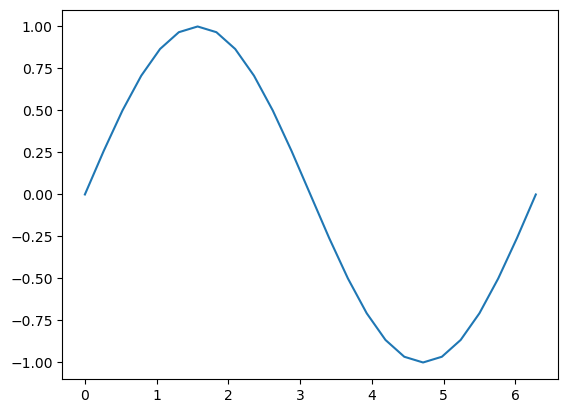

In [5]:
# Aplicamos la función seno elemento a elemento sobre "a"; "b" mantiene historial de gradientes (grad_fn) para autograd.
# La función sin() devuelve un nuevo tensor.
b = torch.sin(a)
# detach() evita pasar tensores con gradientes activos a matplotlib (usa copias sin seguimiento)
plt.plot(a.detach(), b.detach())  

Let's have a closer look at the tensor `b`. When we print it, we see an
indicator that it is tracking its computation history:


In [6]:
print(b)

tensor([ 0.0000e+00,  2.5882e-01,  5.0000e-01,  7.0711e-01,  8.6603e-01,
         9.6593e-01,  1.0000e+00,  9.6593e-01,  8.6603e-01,  7.0711e-01,
         5.0000e-01,  2.5882e-01, -8.7423e-08, -2.5882e-01, -5.0000e-01,
        -7.0711e-01, -8.6603e-01, -9.6593e-01, -1.0000e+00, -9.6593e-01,
        -8.6603e-01, -7.0711e-01, -5.0000e-01, -2.5882e-01,  1.7485e-07],
       grad_fn=<SinBackward0>)


This `grad_fn` gives us a hint that when we execute the backpropagation
step and compute gradients, we'll need to compute the derivative of
$\sin(x)$ for all this tensor's inputs.

Let's perform some more computations:


In [7]:
# Escalamos la salida previa: c = 2·sin(a). Esta operación queda registrada en el grafo de autograd
c = 2 * b
print(c)  # Mostramos c para inspeccionar valores y su grad_fn

# Sumamos una constante a cada elemento (desplazamiento vertical): d = c + 1
d = c + 1
print(d)  # Mostramos d, que será la base para calcular una salida escalar después

tensor([ 0.0000e+00,  5.1764e-01,  1.0000e+00,  1.4142e+00,  1.7321e+00,
         1.9319e+00,  2.0000e+00,  1.9319e+00,  1.7321e+00,  1.4142e+00,
         1.0000e+00,  5.1764e-01, -1.7485e-07, -5.1764e-01, -1.0000e+00,
        -1.4142e+00, -1.7321e+00, -1.9319e+00, -2.0000e+00, -1.9319e+00,
        -1.7321e+00, -1.4142e+00, -1.0000e+00, -5.1764e-01,  3.4969e-07],
       grad_fn=<MulBackward0>)
tensor([ 1.0000e+00,  1.5176e+00,  2.0000e+00,  2.4142e+00,  2.7321e+00,
         2.9319e+00,  3.0000e+00,  2.9319e+00,  2.7321e+00,  2.4142e+00,
         2.0000e+00,  1.5176e+00,  1.0000e+00,  4.8236e-01, -3.5763e-07,
        -4.1421e-01, -7.3205e-01, -9.3185e-01, -1.0000e+00, -9.3185e-01,
        -7.3205e-01, -4.1421e-01,  4.7684e-07,  4.8236e-01,  1.0000e+00],
       grad_fn=<AddBackward0>)


Finally, let's compute a single-element output. When you call
`.backward()` on a tensor with no arguments, it expects the calling
tensor to contain only a single element, as is the case when computing a
loss function.


In [8]:
# Reducimos el tensor d (25 elementos) a un único escalar sumando todos sus valores.
# Esto facilita llamar a backward() sin pasar gradientes externos, porque autograd espera un escalar de salida en este caso.
out = d.sum()
print(out)  # Mostramos el valor escalar final que actuará como "loss" en este ejemplo didáctico

"""                   --- CALCULO DEL 25 ---

- b = sin(a)
- c = 2 * b
- d = c + 1
- out = sum(d)

Sustituyendo paso a paso:
- d = 2 * sin(a) + 1
- out = sum(2 * sin(a) + 1)

Separando la suma:
- out = 2 * sum(sin(a)) + sum(1)

                    out = sum(2 * sin(a) + 1)
                    Eso significa “sumar elemento a elemento”:
                    (2*sin(a1)+1) + (2*sin(a2)+1) + ... + (2*sin(an)+1)
                    
                    Ahora agrupas términos semejantes:
                    2*sin(a1) + 2*sin(a2) + ... + 2*sin(an) + 1+1+...+1
                    Sacas el factor común 2 del primer grupo:
                        2 * (sin(a1)+sin(a2)+...+sin(an)) + sum(1)
                    
                    Y eso es exactamente:
                    out = 2 * sum(sin(a)) + sum(1)
                    
                    Regla general que se está usando:
                    sum(x + y) = sum(x) + sum(y)
                    sum(c * x) = c * sum(x) (si c es constante).

- Como hay 25 elementos: sum(1) = 25
                    Lo correcto sería leerlo como:
                    sum_{i=1..25}(1)
                    o en texto: “sumar 1 veinticinco veces”.
                    
                    Entonces:
                    1 + 1 + 1 + ... + 1 (25 términos) = 25.
                    Por eso aparece 25: porque tu tensor d tiene 25 elementos
- Entonces: out = 2 * sum(sin(a)) + 25

Resultado en este caso:
- Los puntos de a van de 0 a 2*pi y son simétricos
- Por eso sum(sin(a)) ≈ 0
- Finalmente: out ≈ 25
"""

tensor(25., grad_fn=<SumBackward0>)


'                   --- CALCULO DEL 25 ---\n\n- b = sin(a)\n- c = 2 * b\n- d = c + 1\n- out = sum(d)\n\nSustituyendo paso a paso:\n- d = 2 * sin(a) + 1\n- out = sum(2 * sin(a) + 1)\n\nSeparando la suma:\n- out = 2 * sum(sin(a)) + sum(1)\n\n                    out = sum(2 * sin(a) + 1)\n                    Eso significa “sumar elemento a elemento”:\n                    (2*sin(a1)+1) + (2*sin(a2)+1) + ... + (2*sin(an)+1)\n\n                    Ahora agrupas términos semejantes:\n                    2*sin(a1) + 2*sin(a2) + ... + 2*sin(an) + 1+1+...+1\n                    Sacas el factor común 2 del primer grupo:\n                        2 * (sin(a1)+sin(a2)+...+sin(an)) + sum(1)\n\n                    Y eso es exactamente:\n                    out = 2 * sum(sin(a)) + sum(1)\n\n                    Regla general que se está usando:\n                    sum(x + y) = sum(x) + sum(y)\n                    sum(c * x) = c * sum(x) (si c es constante).\n\n- Como hay 25 elementos: sum(1) = 25\n    

Each `grad_fn` stored with our tensors allows you to walk the
computation all the way back to its inputs with its `next_functions`
property. We can see below that drilling down on this property on `d`
shows us the gradient functions for all the prior tensors. Note that
`a.grad_fn` is reported as `None`, indicating that this was an input to
the function with no history of its own.


In [9]:
print('d:')  # Encabezado para inspeccionar el nodo d en el grafo
print(d.grad_fn)  # Función de autograd que creó d (operación suma con constante)
print(d.grad_fn.next_functions)  # Nodos previos conectados a d
print(d.grad_fn.next_functions[0][0].next_functions)  # Descendemos un nivel más en la cadena
print(d.grad_fn.next_functions[0][0].next_functions[0][0].next_functions)  # Seguimos hacia el origen de los datos
print(d.grad_fn.next_functions[0][0].next_functions[0][0].next_functions[0][0].next_functions)  # Último enlace: debería acercarse al tensor hoja
print('\nc:')  # Encabezado para c
print(c.grad_fn)  # Función que creó c (multiplicación por 2)
print('\nb:')  # Encabezado para b
print(b.grad_fn)  # Función que creó b (sin(a))
print('\na:')  # Encabezado para a
print(a.grad_fn)  # a es tensor hoja creado por el usuario, por eso normalmente es None

d:
((<MulBackward0 object at 0x7f22f6fc86d0>, 0), (None, 0))
((<SinBackward0 object at 0x7f23b6210280>, 0), (None, 0))
((<AccumulateGrad object at 0x7f22f6fc86d0>, 0),)
()

c:

b:

a:
None


With all this machinery in place, how do we get derivatives out? You
call the `backward()` method on the output, and check the input's `grad`
property to inspect the gradients:


tensor([ 2.0000e+00,  1.9319e+00,  1.7321e+00,  1.4142e+00,  1.0000e+00,
         5.1764e-01, -8.7423e-08, -5.1764e-01, -1.0000e+00, -1.4142e+00,
        -1.7321e+00, -1.9319e+00, -2.0000e+00, -1.9319e+00, -1.7321e+00,
        -1.4142e+00, -1.0000e+00, -5.1764e-01,  2.3850e-08,  5.1764e-01,
         1.0000e+00,  1.4142e+00,  1.7321e+00,  1.9319e+00,  2.0000e+00])


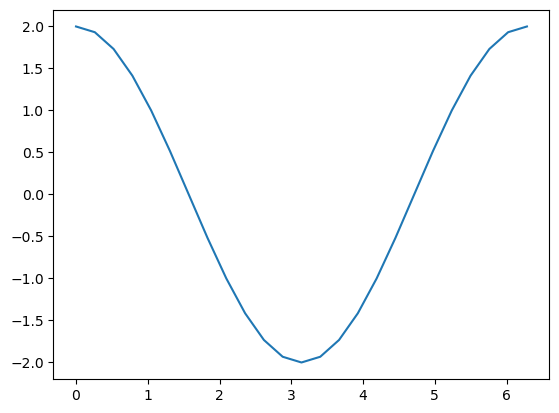

In [10]:
out.backward()  # Ejecuta backpropagation desde el escalar out y calcula gradientes en los tensores hoja
print(a.grad)  # Muestra ∂out/∂a para cada elemento de a (el gradiente acumulado en a)
plt.plot(a.detach(), a.grad.detach())  # Graficamos entrada vs gradiente; detach() evita que matplotlib reciba tensores con seguimiento de gradiente

Recall the computation steps we took to get here:

``` {.python}
a = torch.linspace(0., 2. * math.pi, steps=25, requires_grad=True)
b = torch.sin(a)
c = 2 * b
d = c + 1
out = d.sum()
```

Adding a constant, as we did to compute `d`, does not change the
derivative. That leaves $c = 2 * b = 2 * \sin(a)$, the derivative of
which should be $2 * \cos(a)$. Looking at the graph above, that's just
what we see.

Be aware that only *leaf nodes* of the computation have their gradients
computed. If you tried, for example, `print(c.grad)` you'd get back
`None`. In this simple example, only the input is a leaf node, so only
it has gradients computed.

Autograd in Training
====================

We've had a brief look at how autograd works, but how does it look when
it's used for its intended purpose? Let's define a small model and
examine how it changes after a single training batch. First, define a
few constants, our model, and some stand-ins for inputs and outputs:


In [11]:
# Tamaño del lote (número de ejemplos procesados juntos en cada paso)
BATCH_SIZE = 16
# Dimensión de entrada de cada ejemplo. 1000 CARACTERÍSTICAS de entrada por ejemplo.
DIM_IN = 1000
# Número de neuronas en la capa oculta
HIDDEN_SIZE = 100
# Dimensión de salida del modelo. 10 CLASES de salida por ejemplo.
DIM_OUT = 10

# Modelo pequeño de ejemplo con 2 capas lineales y una activación ReLU entre ellas
class TinyModel(torch.nn.Module):

    def __init__(self):
        super(TinyModel, self).__init__()
        
        # Primera transformación lineal: de DIM_IN a HIDDEN_SIZE
        self.layer1 = torch.nn.Linear(DIM_IN, HIDDEN_SIZE)
        # Activación no lineal
        self.relu = torch.nn.ReLU()
        # Segunda transformación lineal: de HIDDEN_SIZE a DIM_OUT
        self.layer2 = torch.nn.Linear(HIDDEN_SIZE, DIM_OUT)
    
    def forward(self, x):
        # Paso 1: proyección lineal de entrada
        x = self.layer1(x)
        # Paso 2: no linealidad
        x = self.relu(x)
        # Paso 3: proyección a espacio de salida
        x = self.layer2(x)
        return x
    
# Datos sintéticos de entrada (sin gradiente, no son parámetros entrenables)
some_input = torch.randn(BATCH_SIZE, DIM_IN, requires_grad=False)
# Mostramos la forma del tensor de entrada para confirmar dimensiones
print(f"Shape of some_input: {some_input.shape}\n")  
# Mostramos el tensor de entrada para inspeccionar sus valores
print(some_input, "\n")  

# Salida objetivo sintética para calcular la pérdida
ideal_output = torch.randn(BATCH_SIZE, DIM_OUT, requires_grad=False)
# Confirmamos dimensiones de la salida objetivo
print(f"Shape of ideal_output: {ideal_output.shape}\n")  
# Mostramos el tensor de salida objetivo
print(ideal_output)  

# Instanciamos el modelo
model = TinyModel()

Shape of some_input: torch.Size([16, 1000])

tensor([[ 0.1494,  0.7739, -0.8079,  ...,  1.5237,  0.6175,  1.0146],
        [-1.8986, -0.7363, -1.4767,  ..., -0.0569,  0.6804, -0.1535],
        [ 0.3138,  0.2006, -2.2608,  ...,  0.3288, -0.1495, -0.1409],
        ...,
        [-0.1581,  0.5986,  0.0592,  ...,  1.1217,  0.3817, -0.8674],
        [-0.7277, -1.6789, -0.7147,  ..., -1.0442, -0.7261,  0.7214],
        [-0.7050, -1.3847, -0.6863,  ...,  1.4496, -0.1130,  1.3593]]) 

Shape of ideal_output: torch.Size([16, 10])

tensor([[ 0.2271, -0.5750, -1.2679,  0.2154,  0.2209, -0.5705, -0.0052,  1.5617,
          0.7762,  0.8593],
        [-0.7763,  0.9811,  0.1722,  1.1794, -1.7206, -0.2502,  1.0182, -0.7116,
          1.1218,  0.4144],
        [ 0.6316,  0.4349, -0.8872,  0.1816,  1.3777,  0.5501, -0.0316,  0.0241,
         -0.3673, -1.1981],
        [ 0.1191,  0.0546,  0.1594,  0.3959,  0.2519, -0.3080,  1.3002,  0.2631,
         -0.2925,  0.4229],
        [ 0.3449,  0.1323,  1.0124,  1

One thing you might notice is that we never specify `requires_grad=True`
for the model's layers. Within a subclass of `torch.nn.Module`, it's
assumed that we want to track gradients on the layers' weights for
learning.

If we look at the layers of the model, we can examine the values of the
weights, and verify that no gradients have been computed yet:


In [12]:
# Mostramos una pequeña porción de los pesos de la capa de salida para inspeccionar sus valores iniciales.
print(model.layer2.weight[0][0:10])
# Antes de backward(), este gradiente suele ser None porque aún no se han calculado derivadas.
print(model.layer2.weight.grad)  

tensor([-0.0655, -0.0381,  0.0022, -0.0054,  0.0149, -0.0243, -0.0178,  0.0050,
        -0.0290, -0.0911], grad_fn=<SliceBackward0>)
None


Let's see how this changes when we run through one training batch. For a
loss function, we'll just use the square of the Euclidean distance
between our `prediction` and the `ideal_output`, and we'll use a basic
stochastic gradient descent optimizer.


In [13]:
# Definimos el optimizador SGD sobre todos los parámetros entrenables del modelo (lr = tamaño del paso de actualización)
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)

# Hacemos una pasada hacia adelante (forward pass) para obtener predicciones del modelo
prediction = model(some_input)

# Calculamos una pérdida escalar: suma del error cuadrático entre salida ideal y predicción
loss = (ideal_output - prediction).pow(2).sum()
print(loss)  # Mostramos el valor actual de la pérdida antes de backpropagation

tensor(136.4795, grad_fn=<SumBackward0>)


Now, let's call `loss.backward()` and see what happens:


In [14]:
# Propaga la pérdida hacia atrás y calcula gradientes para todos los "parámetros entrenables". 
# Los "parámetros entrenables" son los pesos y sesgos de las capas lineales, que tienen requires_grad=True por defecto.
loss.backward()  
print(model.layer2.weight[0][0:10])  # Mostramos una porción de pesos: aún no cambian hasta llamar a optimizer.step()
print(model.layer2.weight.grad[0][0:10])  # Mostramos los gradientes recién calculados para esos mismos pesos

tensor([-0.0655, -0.0381,  0.0022, -0.0054,  0.0149, -0.0243, -0.0178,  0.0050,
        -0.0290, -0.0911], grad_fn=<SliceBackward0>)
tensor([ -5.9282, -10.1948,  -2.0935,  -5.6664,  -0.7265,   1.9614,  -0.3883,
         -7.4307,  -5.0701,  -4.8363])


We can see that the gradients have been computed for each learning
weight, but the weights remain unchanged, because we haven't run the
optimizer yet. The optimizer is responsible for updating model weights
based on the computed gradients.


In [15]:
optimizer.step()  # Actualiza los pesos del modelo usando los gradientes calculados y la tasa de aprendizaje (lr)
print(model.layer2.weight[0][0:10])  # Ahora sí deberían verse cambios en los pesos tras el paso del optimizador
print(model.layer2.weight.grad[0][0:10])  # Los gradientes permanecen almacenados hasta llamar a optimizer.zero_grad()

tensor([-0.0595, -0.0279,  0.0043,  0.0003,  0.0156, -0.0263, -0.0174,  0.0124,
        -0.0239, -0.0863], grad_fn=<SliceBackward0>)
tensor([ -5.9282, -10.1948,  -2.0935,  -5.6664,  -0.7265,   1.9614,  -0.3883,
         -7.4307,  -5.0701,  -4.8363])


You should see that `layer2`'s weights have changed.

One important thing about the process: After calling `optimizer.step()`,
you need to call `optimizer.zero_grad()`, or else every time you run
`loss.backward()`, the gradients on the learning weights will
accumulate:


In [16]:
# Gradientes actuales antes de repetir backward()
print(f"Gradientes actuales antes de repetir backward():\n")
print(model.layer2.weight.grad[0][0:10])  

for i in range(0, 5):
    prediction = model(some_input)  # Nuevo forward pass
    loss = (ideal_output - prediction).pow(2).sum()  # Recalculamos la pérdida
    loss.backward()  # Acumula gradientes sobre los existentes (no los reemplaza)

# Deberían ser mayores por la acumulación tras 5 backward()    
print(f"\nGradientes después de 5 backward() sin limpiar:\n")
print(model.layer2.weight.grad[0][0:10])  

#                                       --- IMPORTANTE---   
# Reinicia gradientes a cero para evitar acumulación en el siguiente paso
optimizer.zero_grad(set_to_none=False)  

print(f"\nGradientes después de optimizer.zero_grad():\n")
print(model.layer2.weight.grad[0][0:10])  # Ahora los gradientes deberían verse en cero

Gradientes actuales antes de repetir backward():

tensor([ -5.9282, -10.1948,  -2.0935,  -5.6664,  -0.7265,   1.9614,  -0.3883,
         -7.4307,  -5.0701,  -4.8363])

Gradientes después de 5 backward() sin limpiar:

tensor([ -9.4819, -37.4590, -15.7732, -33.9456,  -7.2568,  13.8441,   0.5912,
        -25.0154, -12.1707, -14.8254])

Gradientes después de optimizer.zero_grad():

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])


After running the cell above, you should see that after running
`loss.backward()` multiple times, the magnitudes of most of the
gradients will be much larger. Failing to zero the gradients before
running your next training batch will cause the gradients to blow up in
this manner, causing incorrect and unpredictable learning results.

Turning Autograd Off and On
===========================

There are situations where you will need fine-grained control over
whether autograd is enabled. There are multiple ways to do this,
depending on the situation.

The simplest is to change the `requires_grad` flag on a tensor directly:


In [17]:
a = torch.ones(2, 3, requires_grad=True)  # Tensor inicial con autograd activado
print(f"Tensor a:\n {a}\n")  # Mostramos el tensor a para inspeccionar sus valores iniciales

b1 = 2 * a  # Esta operación queda registrada en el grafo porque a requiere gradiente
print(f"Tensor b1:\n {b1}\n")  # Mostramos b1 para confirmar que se ha creado correctamente y tiene grad_fn

a.requires_grad = False  # Desactivamos el seguimiento de gradientes para a
b2 = 2 * a  # Ahora esta operación ya no se rastrea por autograd
print(f"Tensor b2 tras desactivar seguimiento de gradientes para tensor a:\n {b2}\n")  # Mostramos b2 para confirmar que se ha creado pero sin grad_fn
print(f"Gradiente de b1:\n {b1.grad_fn}\n")
print(f"Gradiente de b2:\n {b2.grad_fn}\n")

Tensor a:
 tensor([[1., 1., 1.],
        [1., 1., 1.]], requires_grad=True)

Tensor b1:
 tensor([[2., 2., 2.],
        [2., 2., 2.]], grad_fn=<MulBackward0>)

Tensor b2 tras desactivar seguimiento de gradientes para tensor a:
 tensor([[2., 2., 2.],
        [2., 2., 2.]])

Gradiente de b1:

Gradiente de b2:
 None



In the cell above, we see that `b1` has a `grad_fn` (i.e., a traced
computation history), which is what we expect, since it was derived from
a tensor, `a`, that had autograd turned on. When we turn off autograd
explicitly with `a.requires_grad = False`, computation history is no
longer tracked, as we see when we compute `b2`.

If you only need autograd turned off temporarily, a better way is to use
the `torch.no_grad()`:


In [18]:
a = torch.ones(2, 3, requires_grad=True) * 2  # Tensor con autograd activo
b = torch.ones(2, 3, requires_grad=True) * 3  # Otro tensor con autograd activo

c1 = a + b  # Esta suma sí se registra en el grafo de autograd
print(f"\nSuma de tensores a y b con seguimiento de gradientes:\n {c1}\n")  # Debería mostrar grad_fn

# Dentro de este bloque NO se registra historial de gradientes
with torch.no_grad():
    c2 = a + b  

print(f"Suma de tensores a y b sin seguimiento de gradientes:\n {c2}\n")  # Debería aparecer sin grad_fn

c3 = a * b  # Fuera del bloque, autograd vuelve a estar activo
print(f"Producto de tensores a y b con seguimiento de gradientes:\n {c3}\n")  # Debería mostrar grad_fn nuevamente


Suma de tensores a y b con seguimiento de gradientes:
 tensor([[5., 5., 5.],
        [5., 5., 5.]], grad_fn=<AddBackward0>)

Suma de tensores a y b sin seguimiento de gradientes:
 tensor([[5., 5., 5.],
        [5., 5., 5.]])

Producto de tensores a y b con seguimiento de gradientes:
 tensor([[6., 6., 6.],
        [6., 6., 6.]], grad_fn=<MulBackward0>)



`torch.no_grad()` can also be used as a function or method decorator:


In [19]:
# Función normal: las operaciones dentro de esta función sí se registran en el grafo si las entradas requieren gradiente
def add_tensors1(x, y):
    return x + y

# Decorador que desactiva autograd solo durante la ejecución de esta función
@torch.no_grad()
def add_tensors2(x, y):
    return x + y


# Tensores de ejemplo con requires_grad=True para observar la diferencia entre ambas funciones
a = torch.ones(2, 3, requires_grad=True) * 2
b = torch.ones(2, 3, requires_grad=True) * 3

# Esta llamada conserva el seguimiento de gradientes (resultado con grad_fn)
c1 = add_tensors1(a, b)
print(f"Suma de tensores a y b con seguimiento de gradientes:\n {c1}\n")

# Esta llamada NO conserva el seguimiento de gradientes por el decorador no_grad
c2 = add_tensors2(a, b)
print(f"Suma de tensores a y b sin seguimiento de gradientes:\n {c2}\n")

Suma de tensores a y b con seguimiento de gradientes:
 tensor([[5., 5., 5.],
        [5., 5., 5.]], grad_fn=<AddBackward0>)

Suma de tensores a y b sin seguimiento de gradientes:
 tensor([[5., 5., 5.],
        [5., 5., 5.]])



There's a corresponding context manager, `torch.enable_grad()`, for
turning autograd on when it isn't already. It may also be used as a
decorator.

Finally, you may have a tensor that requires gradient tracking, but you
want a copy that does not. For this we have the `Tensor` object's
`detach()` method - it creates a copy of the tensor that is *detached*
from the computation history:


In [20]:
# Creamos un tensor aleatorio con seguimiento de gradientes activado
x = torch.rand(5, requires_grad=True)

# detach() crea una vista/copia desconectada del grafo: comparte datos pero sin historial de autograd
y = x.detach()

# x mantiene requires_grad=True y puede participar en backward()
print(f"Tensor x con seguimiento de gradientes {x.requires_grad}\n{x}\n")  # Mostramos x para confirmar que tiene requires_grad=True

# y tiene los mismos valores actuales, pero sin grad_fn ni seguimiento de gradientes
print(f"Tensor y sin seguimiento de gradientes {y.requires_grad}\n{y}\n")  # Mostramos y para confirmar que no tiene requires_grad y no tiene grad_fn

Tensor x con seguimiento de gradientes True
tensor([0.8909, 0.2869, 0.4032, 0.6551, 0.8473], requires_grad=True)

Tensor y sin seguimiento de gradientes False
tensor([0.8909, 0.2869, 0.4032, 0.6551, 0.8473])



We did this above when we wanted to graph some of our tensors. This is
because `matplotlib` expects a NumPy array as input, and the implicit
conversion from a PyTorch tensor to a NumPy array is not enabled for
tensors with requires\_grad=True. Making a detached copy lets us move
forward.

Autograd and In-place Operations
================================

In every example in this notebook so far, we've used variables to
capture the intermediate values of a computation. Autograd needs these
intermediate values to perform gradient computations. *For this reason,
you must be careful about using in-place operations when using
autograd.* Doing so can destroy information you need to compute
derivatives in the `backward()` call. PyTorch will even stop you if you
attempt an in-place operation on leaf variable that requires autograd,
as shown below.

<div style="background-color: #54c7ec; color: #fff; font-weight: 700; padding-left: 10px; padding-top: 5px; padding-bottom: 5px"><strong>NOTE:</strong></div>

<div style="background-color: #f3f4f7; padding-left: 10px; padding-top: 10px; padding-bottom: 10px; padding-right: 10px">

<p>The following code cell throws a runtime error. This is expected.<pre><code>a = torch.linspace(0., 2. * math.pi, steps=25, requires_grad=True)
torch.sin_(a)</code></pre></p>

</div>



Autograd Profiler
=================

Autograd tracks every step of your computation in detail. Such a
computation history, combined with timing information, would make a
handy profiler - and autograd has that feature baked in. Here's a quick
example usage:


In [21]:
# Seleccionamos CPU por defecto; cambiaremos a GPU si está disponible
device = torch.device('cpu')
run_on_gpu = False  # Bandera para indicar al profiler si debe usar métricas CUDA
if torch.cuda.is_available():
    device = torch.device('cuda')  # Si hay CUDA, marcamos dispositivo GPU
    run_on_gpu = True  # Activamos modo GPU para el profiler
    print(f"CUDA esta disponible. Usando GPU para el perfilado de autograd.\n")
else:
    print(f"CUDA no esta disponible. Usando CPU para el perfilado de autograd.\n")
        
# Creamos tensores de ejemplo con requires_grad=True para que autograd rastree operaciones
x = torch.randn(2, 3, requires_grad=True)
y = torch.rand(2, 3, requires_grad=True)
z = torch.ones(2, 3, requires_grad=True)

# Iniciamos el perfilador de autograd; use_cuda depende de si estamos en GPU
with torch.autograd.profiler.profile(use_cuda=run_on_gpu) as prf:
    for _ in range(1000):  # Repetimos muchas veces para obtener tiempos más representativos
        z = (z / x) * y  # Operación simple rastreada por autograd
        
# Mostramos tabla agregada de tiempos, ordenada por tiempo propio de CPU
print(prf.key_averages().table(sort_by='self_cpu_time_total'))

CUDA no esta disponible. Usando CPU para el perfilado de autograd.

-------------  ------------  ------------  ------------  ------------  ------------  ------------  
         Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg    # of Calls  
-------------  ------------  ------------  ------------  ------------  ------------  ------------  
    aten::div        50.50%       7.506ms        50.50%       7.506ms       7.506us          1000  
    aten::mul        49.50%       7.358ms        49.50%       7.358ms       7.358us          1000  
-------------  ------------  ------------  ------------  ------------  ------------  ------------  
Self CPU time total: 14.864ms



ERROR:2026-03-03 10:23:39 1000643:1000643 DeviceProperties.cpp:47] gpuGetDeviceCount failed with code 35


The profiler can also label individual sub-blocks of code, break out the
data by input tensor shape, and export data as a Chrome tracing tools
file. For full details of the API, see the
[documentation](https://pytorch.org/docs/stable/autograd.html#profiler).

Advanced Topic: More Autograd Detail and the High-Level API
===========================================================

If you have a function with an n-dimensional input and m-dimensional
output, $\vec{y}=f(\vec{x})$, the complete gradient is a matrix of the
derivative of every output with respect to every input, called the
*Jacobian:*

$$\begin{aligned}
J
=
\left(\begin{array}{ccc}
\frac{\partial y_{1}}{\partial x_{1}} & \cdots & \frac{\partial y_{1}}{\partial x_{n}}\\
\vdots & \ddots & \vdots\\
\frac{\partial y_{m}}{\partial x_{1}} & \cdots & \frac{\partial y_{m}}{\partial x_{n}}
\end{array}\right)
\end{aligned}$$

If you have a second function, $l=g\left(\vec{y}\right)$ that takes
m-dimensional input (that is, the same dimensionality as the output
above), and returns a scalar output, you can express its gradients with
respect to $\vec{y}$ as a column vector,
$v=\left(\begin{array}{ccc}\frac{\partial l}{\partial y_{1}} & \cdots & \frac{\partial l}{\partial y_{m}}\end{array}\right)^{T}$
- which is really just a one-column Jacobian.

More concretely, imagine the first function as your PyTorch model (with
potentially many inputs and many outputs) and the second function as a
loss function (with the model's output as input, and the loss value as
the scalar output).

If we multiply the first function's Jacobian by the gradient of the
second function, and apply the chain rule, we get:

$$\begin{aligned}
J^{T}\cdot v=\left(\begin{array}{ccc}
\frac{\partial y_{1}}{\partial x_{1}} & \cdots & \frac{\partial y_{m}}{\partial x_{1}}\\
\vdots & \ddots & \vdots\\
\frac{\partial y_{1}}{\partial x_{n}} & \cdots & \frac{\partial y_{m}}{\partial x_{n}}
\end{array}\right)\left(\begin{array}{c}
\frac{\partial l}{\partial y_{1}}\\
\vdots\\
\frac{\partial l}{\partial y_{m}}
\end{array}\right)=\left(\begin{array}{c}
\frac{\partial l}{\partial x_{1}}\\
\vdots\\
\frac{\partial l}{\partial x_{n}}
\end{array}\right)
\end{aligned}$$

Note: You could also use the equivalent operation $v^{T}\cdot J$, and
get back a row vector.

The resulting column vector is the *gradient of the second function with
respect to the inputs of the first* - or in the case of our model and
loss function, the gradient of the loss with respect to the model
inputs.

**\`\`torch.autograd\`\` is an engine for computing these products.**
This is how we accumulate the gradients over the learning weights during
the backward pass.

For this reason, the `backward()` call can *also* take an optional
vector input. This vector represents a set of gradients over the tensor,
which are multiplied by the Jacobian of the autograd-traced tensor that
precedes it. Let's try a specific example with a small vector:


In [ ]:
# Creamos un vector aleatorio de 3 elementos y activamos autograd para poder calcular gradientes respecto a x
x = torch.randn(3, requires_grad=True)
print(f"Vector x con seguimiento de gradientes:\n {x}\n")  # Mostramos x para confirmar que tiene requires_grad=True

# Primera transformación: escalamos x por 2
y = x * 2
print(f"Vector y tras escalar x por 2:\n {y}\n")  # Mostramos y para confirmar que se ha creado correctamente y tiene grad_fn

# Seguimos duplicando y hasta que su norma euclídea sea suficientemente grande
"""
y.data.norm() calcula la norma (por defecto, norma (L2) o euclídea) del tensor y.

        norm() mide el “tamaño” del vector: (|y|_2 = \sqrt{\sum_i y_i^2}).
        Devuelve un escalar (tensor de 0 dimensiones).
        En tu while, se usa para comprobar si y ya es lo bastante grande (< 1000).

Detalle importante: y.data evita autograd y no se recomienda en PyTorch moderno. Es más seguro usar:

y.detach().norm() (si no quieres gradientes), o
y.norm() directamente (si no necesitas romper el grafo).
"""
while y.data.norm() < 1000:
    y = y * 2  # Cada iteración multiplica por 2 y aumenta rápidamente la magnitud del vector

print(f"Vector final y:\n {y}\n")  # Mostramos el vector final (salida no escalar)

Vector x con seguimiento de gradientes:
 tensor([ 0.2471,  2.3723, -1.5780], requires_grad=True)

Vector y tras escalar x por 2:
 tensor([ 0.4943,  4.7445, -3.1560], grad_fn=<MulBackward0>)

Vector final y:
 tensor([ 126.5349, 1214.5999, -807.9473], grad_fn=<MulBackward0>)



If we tried to call `y.backward()` now, we'd get a runtime error and a
message that gradients can only be *implicitly* computed for scalar
outputs. For a multi-dimensional output, autograd expects us to provide
gradients for those three outputs that it can multiply into the
Jacobian:


In [23]:
# Vector de gradientes externos (uno por cada componente de y) para el producto vector-Jacobiano
v = torch.tensor([0.1, 1.0, 0.0001], dtype=torch.float)  # stand-in for gradients
# Como "y" no es escalar, backward() necesita este vector "v" para propagar gradientes correctamente
y.backward(v)

# Mostramos el gradiente resultante respecto a x: ∂L/∂x acumulado por autograd
print(x.grad)

tensor([5.1200e+01, 5.1200e+02, 5.1200e-02])


(Note that the output gradients are all related to powers of two - which
we'd expect from a repeated doubling operation.)

The High-Level API
==================

There is an API on autograd that gives you direct access to important
differential matrix and vector operations. In particular, it allows you
to calculate the Jacobian and the *Hessian* matrices of a particular
function for particular inputs. (The Hessian is like the Jacobian, but
expresses all partial *second* derivatives.) It also provides methods
for taking vector products with these matrices.

Let's take the Jacobian of a simple function, evaluated for a 2
single-element inputs:


In [24]:
# Definimos una función simple de dos entradas para estudiar su Jacobiano
def exp_adder(x, y):
    return 2 * x.exp() + 3 * y  # f(x, y) = 2e^x + 3y

# Creamos un par de tensores de 1 elemento que usaremos como argumentos de entrada
inputs = (torch.rand(1), torch.rand(1)) # arguments for the function
print(inputs)  # Mostramos los valores de entrada donde evaluaremos derivadas parciales
# Calculamos el Jacobiano de exp_adder respecto a (x, y) en el punto indicado por inputs
torch.autograd.functional.jacobian(exp_adder, inputs)

(tensor([0.7864]), tensor([0.0039]))


(tensor([[4.3908]]), tensor([[3.]]))

If you look closely, the first output should equal $2e^x$ (since the
derivative of $e^x$ is $e^x$), and the second value should be 3.

You can, of course, do this with higher-order tensors:


In [25]:
# Ahora usamos tensores de 3 elementos para ver el Jacobiano en un caso vectorial
inputs = (torch.rand(3), torch.rand(3)) # arguments for the function
print(inputs)  # Mostramos las dos entradas (x e y) donde se evaluarán las derivadas parciales
# Calculamos el Jacobiano de exp_adder respecto a ambas entradas en este punto
torch.autograd.functional.jacobian(exp_adder, inputs)

(tensor([0.8500, 0.4663, 0.8566]), tensor([0.4853, 0.2569, 0.7130]))


(tensor([[4.6793, 0.0000, 0.0000],
         [0.0000, 3.1880, 0.0000],
         [0.0000, 0.0000, 4.7101]]),
 tensor([[3., 0., 0.],
         [0., 3., 0.],
         [0., 0., 3.]]))

The `torch.autograd.functional.hessian()` method works identically
(assuming your function is twice differentiable), but returns a matrix
of all second derivatives.

There is also a function to directly compute the vector-Jacobian
product, if you provide the vector:


In [26]:
# Función auxiliar: duplica el vector de entrada hasta que su norma supere un umbral
def do_some_doubling(x):
    y = x * 2  # Primera duplicación
    while y.data.norm() < 1000:  # Repetimos mientras la magnitud (norma L2) siga siendo pequeña
        y = y * 2  # Cada iteración vuelve a duplicar y
    return y

# Vector de entrada sobre el que evaluaremos la función
inputs = torch.randn(3)
# Vector "v" que se usará para calcular el producto vector-Jacobiano (VJP)
my_gradients = torch.tensor([0.1, 1.0, 0.0001])
# Calcula (salida de la función, VJP) para do_some_doubling en el punto indicado por inputs
torch.autograd.functional.vjp(do_some_doubling, inputs, v=my_gradients)

(tensor([ 975.1733, 1308.2963,  923.5237]),
 tensor([2.0480e+02, 2.0480e+03, 2.0480e-01]))

The `torch.autograd.functional.jvp()` method performs the same matrix
multiplication as `vjp()` with the operands reversed. The `vhp()` and
`hvp()` methods do the same for a vector-Hessian product.

For more information, including performance notes on the [docs for the
functional
API](https://pytorch.org/docs/stable/autograd.html#functional-higher-level-api)
